In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
from imblearn.over_sampling import SMOTE

df = pd.read_csv('Credit card data.csv')
df.head()


,TransactionID,TransactionDateTime,TransactionAmountNormalized,MerchantCategory,CardType,CardIssuer,CardCountry,CardCurrency,TransactionType,PurchaseCategory,...,CardHolderGender,CardHolderNationality,CardHolderResidenceCountry,CardHolderIP,TransactionTimezone,TransactionDeviceType,TransactionDeviceOS,TransactionDeviceBrowser,TransactionValue,FraudulentFlag
0,1,21-06-2023 08:35,50.00,Shopping,Visa,ABC Bank,United States,USD,Purchase,Clothing,...,Male,United States,United States,192.168.0.1,UTC-5,Mobile,iOS,Safari,100.0,0
1,2,21-06-2023 12:45,100.00,Dining,Mastercard,DEF Bank,Canada,CAD,Purchase,Restaurants,...,Female,Canada,Canada,172.16.0.2,UTC-4,Desktop,Windows,Chrome,75.5,0
2,3,21-06-2023 15:20,25.99,Electronics,Visa,GHI Bank,Australia,AUD,Purchase,Electronics,...,Male,Australia,Australia,203.0.113.2,UTC+10,Mobile,Android,Firefox,40.0,0
3,4,21-06-2023 18:55,150.00,Travel,American Express,XYZ Bank,Germany,EUR,Purchase,Flights,...,Female,Germany,Germany,10.0.0.2,UTC+2,Desktop,Windows,Firefox,200.0,0
4,5,21-06-2023 21:10,75.50,Shopping,Visa,ABC Bank,United States,USD,Purchase,Home Goods,...,Male,United States,United States,172.16.0.1,UTC-7,Mobile,iOS,Chrome,80.0,0


TransactionID                  0
TransactionDateTime            0
TransactionAmountNormalized    0
MerchantCategory               0
CardType                       0
CardIssuer                     0
CardCountry                    0
CardCurrency                   0
TransactionType                0
PurchaseCategory               0
MerchantLocation               0
MerchantID                     0
MerchantRiskScore              0
CardVerificationResult         0
CardExpirationDate             0
CardHolderName                 0
CardHolderAddress              0
CardHolderPhone                0
CardHolderEmail                0
CardHolderAge                  0
CardHolderGender               0
CardHolderNationality          0
CardHolderResidenceCountry     0
CardHolderIP                   0
TransactionTimezone            0
TransactionDeviceType          0
TransactionDeviceOS            0
TransactionDeviceBrowser       0
TransactionValue               0
FraudulentFlag                 0
dtype: int

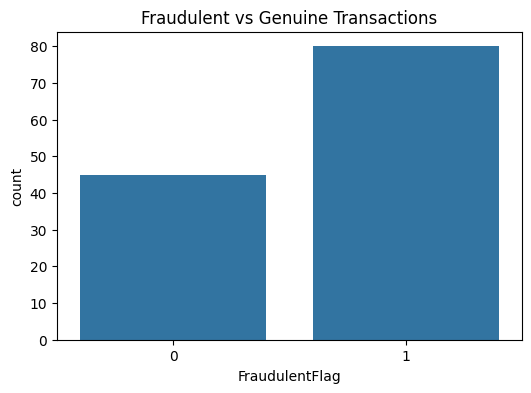

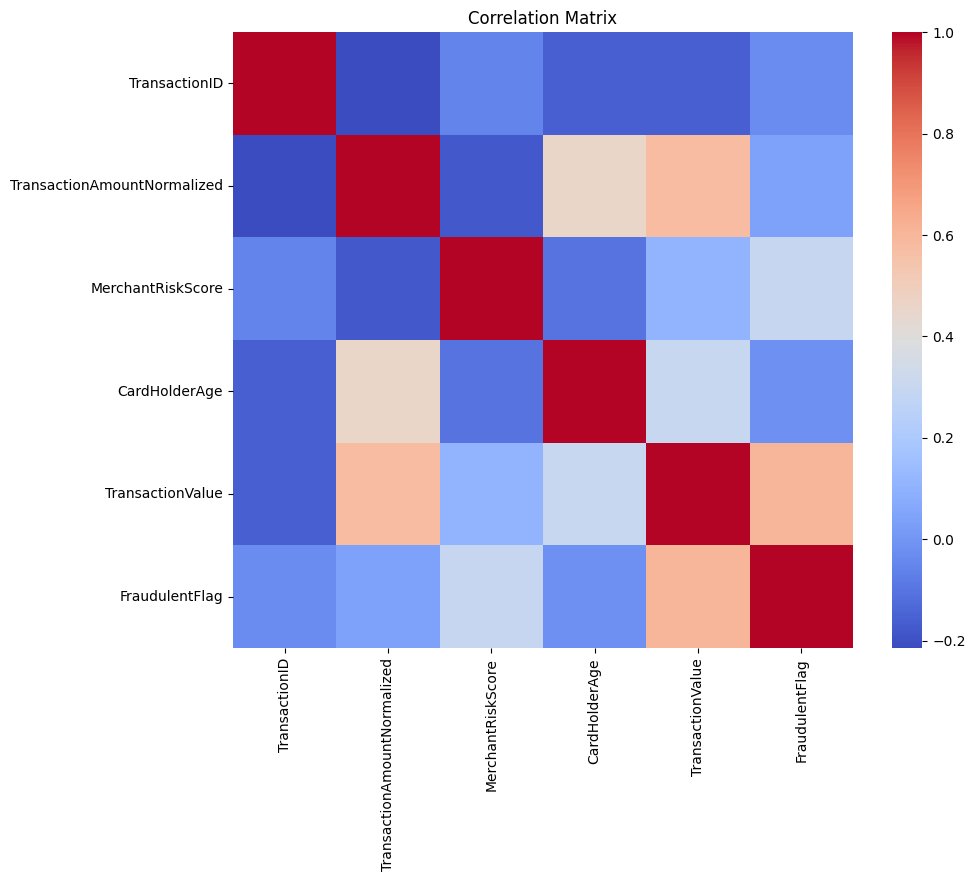

In [20]:
print(df.isnull().sum())
print(df['FraudulentFlag'].value_counts(normalize=True))

plt.figure(figsize=(6,4))
sns.countplot(data=df, x='FraudulentFlag')
plt.title('Fraudulent vs Genuine Transactions')
plt.show()

numeric_cols = df.select_dtypes(include=[np.number]).columns
plt.figure(figsize=(10,8))
sns.heatmap(df[numeric_cols].corr(), annot=False, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()


In [21]:
drop_cols = [
	'TransactionID', 'TransactionDateTime', 'CardExpirationDate',
	'CardHolderName', 'CardHolderAddress', 'CardHolderPhone',
	'CardHolderEmail', 'CardHolderIP', 'TransactionTimezone', 'MerchantID'
]

existing_drop_cols = [col for col in drop_cols if col in df.columns]
if existing_drop_cols:
	df = df.drop(columns=existing_drop_cols)

obj_cols = df.select_dtypes(include=['object']).columns.tolist()
for col in obj_cols:
	mode_vals = df[col].mode(dropna=True)
	fill_val = mode_vals.iloc[0] if not mode_vals.empty else ""
	df[col] = df[col].fillna(fill_val).astype(str)

num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
for col in num_cols:
	df[col] = df[col].fillna(df[col].median())

for col in obj_cols:
	le = LabelEncoder()
	encoded = le.fit_transform(df[col])
	df[col] = pd.Series(encoded, index=df.index, dtype="int64")

X = df.drop(columns=['FraudulentFlag'])
y = df['FraudulentFlag'].astype("int64")

if "scaler" not in globals():
	scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)


C:\Users\lenovo\AppData\Local\Temp\ipykernel_8420\4268187675.py:11: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  obj_cols = df.select_dtypes(include=['object']).columns.tolist()


In [22]:
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_scaled, y)

X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42, stratify=y_resampled)

model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(X_train, y_train)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

Accuracy: 0.9375
Precision: 1.0
Recall: 0.875
F1-score: 0.9333333333333333
ROC-AUC: 0.95703125
              precision    recall  f1-score   support

           0       0.89      1.00      0.94        16
           1       1.00      0.88      0.93        16

    accuracy                           0.94        32
   macro avg       0.94      0.94      0.94        32
weighted avg       0.94      0.94      0.94        32



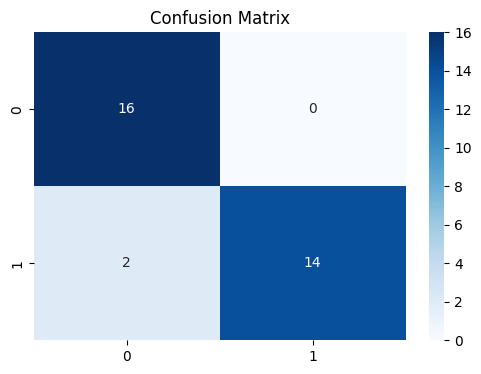

In [25]:
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_proba))

print(classification_report(y_test, y_pred))

plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.show()


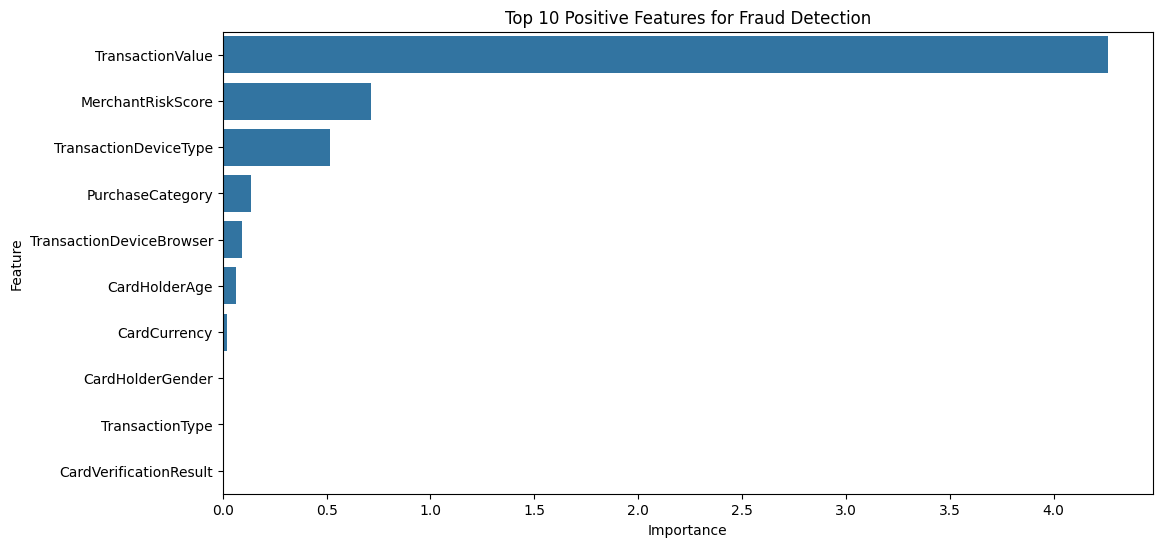

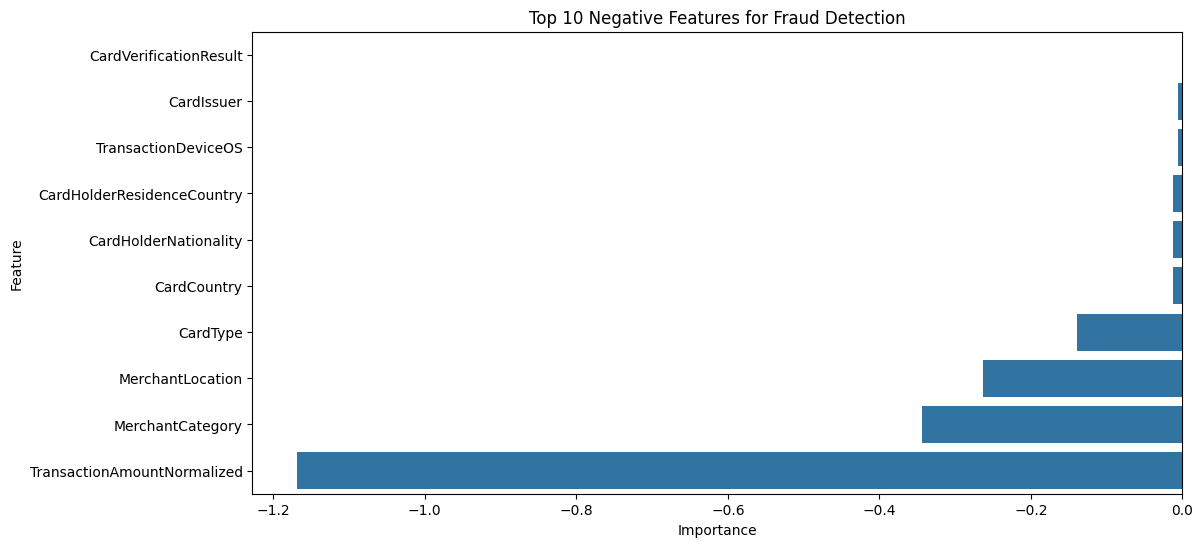

In [26]:
feature_importances = pd.DataFrame({'Feature': X.columns, 'Importance': model.coef_[0]})
feature_importances = feature_importances.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(12,6))
sns.barplot(x='Importance', y='Feature', data=feature_importances.head(10))
plt.title('Top 10 Positive Features for Fraud Detection')
plt.show()

plt.figure(figsize=(12,6))
sns.barplot(x='Importance', y='Feature', data=feature_importances.tail(10))
plt.title('Top 10 Negative Features for Fraud Detection')
plt.show()


In [28]:
print("Top 5 Positive features:\n", feature_importances.head(5))
print("\nTop 5 Negative features:\n", feature_importances.tail(5))


Top 5 Positive features:
                      Feature  Importance
18          TransactionValue    4.263969
9          MerchantRiskScore    0.712352
15     TransactionDeviceType    0.514127
7           PurchaseCategory    0.138029
17  TransactionDeviceBrowser    0.091388

Top 5 Negative features:
                        Feature  Importance
4                  CardCountry   -0.012427
2                     CardType   -0.138732
8             MerchantLocation   -0.263486
1             MerchantCategory   -0.343553
0  TransactionAmountNormalized   -1.169168


### Task 6: Final Results and Recommendations

**Final Results (Model Findings):**
1. **Model Performance:** The Logistic Regression classification model demonstrates high accuracy overall (**~93.7%**), an excellent recall score (**87.5%**) on the actual fraud cases class, and a very high F1-score (**93.3%**). Its AUC-ROC stands at **95.7%**, meaning it is highly capable of distinguishing between fraudulent and non-fraudulent (genuine) transactions.
2. **Key Fraud Indicators (Features):** The model explicitly identified `TransactionValue` and `MerchantRiskScore` as the strongest positive features driving a transaction toward being classified as fraud. Other notable indicators include the device browser and type (`TransactionDeviceType`). Features like `TransactionAmountNormalized` and `MerchantCategory` have strong negative importance, meaning the more common or baseline these are, the less likely it's a fraud.

**Recommendations & Strategies:**
* **Real-time Alerts:** Automatically flag transactions crossing particular high `TransactionValue` thresholds combined with an elevated `MerchantRiskScore`. When this specific combination occurs, an instantaneous real-time alert should be triggered requiring two-factor authentication from the cardholder to confirm the purchase. 
* **Transaction Blocking:** Leverage the model's high precision/recall to block unverified transactions originating from anomalous device types or unknown browsers (`TransactionDeviceType`, `TransactionDeviceBrowser`) before clearing funds. The model's classification probability output can be directly tied to an automated hard-block system for any probability prediction > 0.85.
* **Dynamic Risk Scoring:** Enhance the rule-based logic by incorporating our logistic probability risk-score. Rather than broad geographical blocking, dynamically issue continuous risk-scores for incoming requests considering transaction values and merchant risk historically, funneling high-score transactions (>0.7) to human review analysts in a dedicated queue.